# Empirical Analysis of Exchange Rate Dynamics: A Macroeconomic Framework

## 1. Theoretical Note on Exchange Rates

In open-economy macroeconomics, the exchange rate is a pivotal variable that links domestic and foreign markets, influencing both the real economy and financial flows. It serves as the primary transmission mechanism for exogenous monetary and fiscal shocks across sovereign borders.

### Nominal vs. Real Exchange Rates
The **Nominal Exchange Rate** ($S$) is defined as the relative price of two sovereign currencies. For the purposes of this note, we adopt the standard European quotation convention (indirect quotation): the number of units of foreign currency required to purchase one unit of domestic currency (e.g., USD/EUR). Under this convention, an increase in $S$ signifies an appreciation of the domestic currency.

To evaluate true international competitiveness, financial engineers and macroeconomists rely on the **Real Exchange Rate** ($Q$). This metric adjusts the nominal rate for differential price levels between the domestic and foreign economies:

$Q = S \cdot \frac{P}{P^*}$

Where:
* **$Q$**: Real Exchange Rate.
* **$S$**: Nominal Exchange Rate.
* **$P$**: Domestic price level (e.g., GDP Deflator or CPI).
* **$P^*$**: Foreign price level.

### Macroeconomic Significance and Net Exports
The real exchange rate directly dictates the trajectory of the Net Exports ($NX$) component of the Gross Domestic Product ($Y = C + I + G + NX$). Assuming the Marshall-Lerner condition holds, Net Exports are a decreasing function of the real exchange rate:

$NX = NX(Q, Y, Y^*)$

A depreciation in the real exchange rate (a decline in $Q$) stimulates foreign demand for domestic exports ($X$) and suppresses domestic demand for foreign imports ($M$), holding domestic ($Y$) and foreign ($Y^*$) income constant. 

### Historical Volatility
In financial engineering, historical volatility ($\sigma$) is standardly estimated using the sample standard deviation of daily logarithmic returns, scaled by the square root of the number of trading periods in a year (typically 252 for Forex).

$\sigma_t = \sqrt{252} \cdot \sqrt{\frac{1}{n-1} \sum_{i=0}^{n-1} \left( r_{t-i} - \bar{r}_t \right)^2}$

In [6]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%load_ext sql
%sql duckdb:///:memory:

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [7]:
%%sql
INSTALL httpfs;
LOAD httpfs;
INSTALL json;
LOAD json;

Running query in 'duckdb:///:memory:'

Success


In [8]:
%%sql fx_matrix <<
WITH ecb_raw AS (
    -- Scarica USD, GBP, JPY e CHF in un'unica chiamata
    SELECT 
        CAST(TIME_PERIOD AS DATE) AS date,
        CURRENCY AS currency,
        CAST(OBS_VALUE AS DOUBLE) AS exchange_rate
    FROM read_csv_auto('https://data-api.ecb.europa.eu/service/data/EXR/D.USD+GBP+JPY+CHF.EUR.SP00.A?format=csvdata')
    WHERE OBS_VALUE IS NOT NULL
)
-- Trasforma i dati da formato lungo a formato largo (matrice)
PIVOT ecb_raw 
ON currency 
USING FIRST(exchange_rate)
GROUP BY date
ORDER BY date ASC;

Running query in 'duckdb:///:memory:'

## 1. Cross-Asset Correlation Matrix

We compute the Pearson correlation matrix on the daily logarithmic returns of the nominal exchange rates to identify linear dependencies across sovereign currency pairs.

In [9]:
# Converte il risultato di DuckDB in un DataFrame Pandas
df_fx = fx_matrix.DataFrame()
df_fx['date'] = pd.to_datetime(df_fx['date'])
df_fx.set_index('date', inplace=True)

# Calcola i log-rendimenti giornalieri per tutte le valute
df_returns = np.log(df_fx / df_fx.shift(1)).dropna()

# Calcola la matrice di correlazione di Pearson
corr_matrix = df_returns.corr()

print("--- Cross-Asset Correlation Matrix (Daily Log Returns) ---")
display(corr_matrix.style.background_gradient(cmap='coolwarm', axis=None).format("{:.3f}"))

--- Cross-Asset Correlation Matrix (Daily Log Returns) ---


,CHF,GBP,JPY,USD
CHF,1.000,0.090,0.340,0.193
GBP,0.090,1.000,0.219,0.422
JPY,0.340,0.219,1.000,0.550
USD,0.193,0.422,0.550,1.000


## 2. Target Asset Analysis: Nominal Trajectory and Volatility

Isolating a specific currency to visualize its localized risk profile via a 30-day rolling annualized volatility metric.

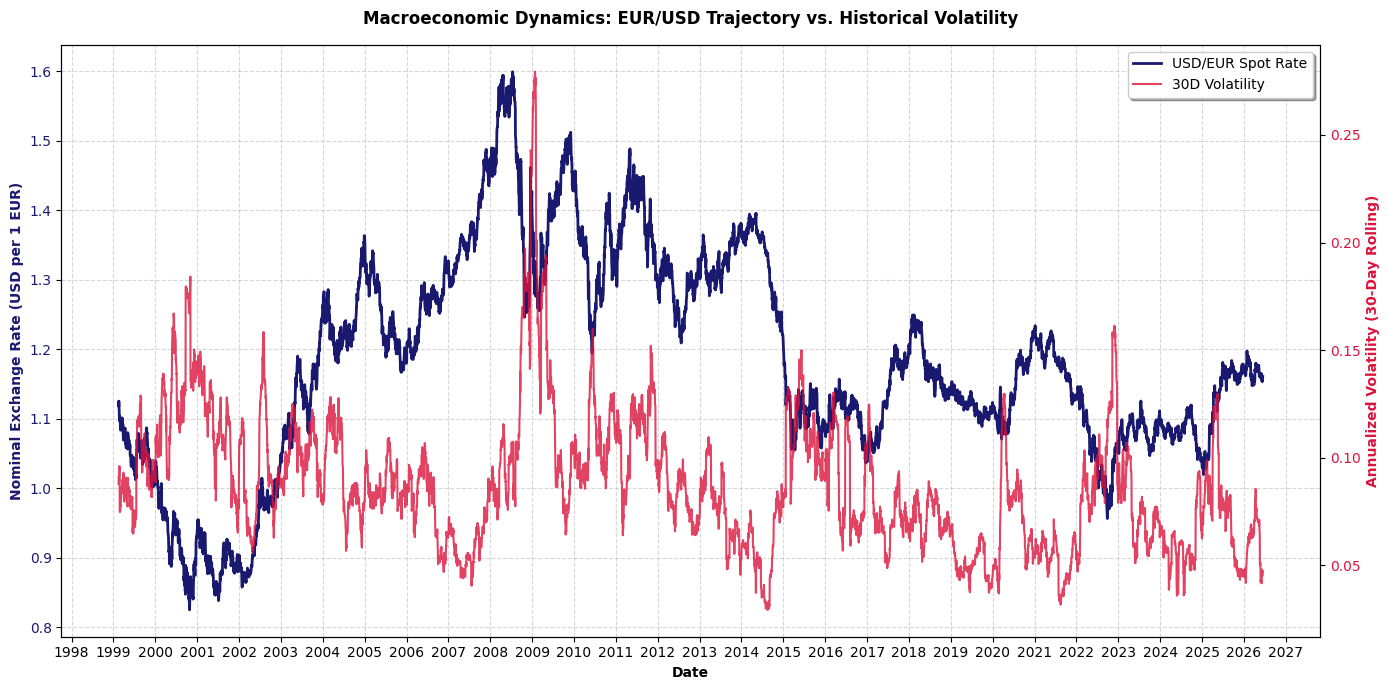

In [10]:
# Seleziona la valuta da analizzare (puoi cambiarla con 'GBP', 'JPY' o 'CHF')
target_currency = 'USD'

# Calcola la volatilità storica a 30 giorni (annualizzata)
df_fx['volatility_30d'] = df_returns[target_currency].rolling(window=30).std() * np.sqrt(252)

# Rimuove i valori NaN generati dalla finestra rolling
df_plot = df_fx.dropna(subset=['volatility_30d'])

# Creazione del grafico a doppio asse
fig, ax1 = plt.subplots(figsize=(14, 7))

# Asse Principale: Tasso di Cambio Nominale
color1 = 'midnightblue'
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel(f'Nominal Exchange Rate ({target_currency} per 1 EUR)', color=color1, fontweight='bold')
line1 = ax1.plot(df_plot.index, df_plot[target_currency], color=color1, linewidth=2, label=f'{target_currency}/EUR Spot Rate')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.5)

# Asse Secondario: Volatilità Rolling
ax2 = ax1.twinx()  
color2 = 'crimson'
ax2.set_ylabel('Annualized Volatility (30-Day Rolling)', color=color2, fontweight='bold')  
line2 = ax2.plot(df_plot.index, df_plot['volatility_30d'], color=color2, linewidth=1.5, alpha=0.8, label='30D Volatility')
ax2.tick_params(axis='y', labelcolor=color2)

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Unisce le legende
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True, shadow=True)

plt.title(f'Macroeconomic Dynamics: EUR/{target_currency} Trajectory vs. Historical Volatility', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()